1. ライブラリのインポート

In [1]:
import pandas as pd
print('pandas:',pd.__version__)
import seaborn as sns
print('seaborn:',sns.__version__)
import numpy as np
print('numpy:',np.__version__)
import japanize_matplotlib
print('japanize_matplotlib:1.1.3')
import matplotlib
import matplotlib.pyplot as plt
print('matplotlib:',matplotlib.__version__)
import joblib
print('joblib:',joblib.__version__)
import sklearn
print('sklearn:',sklearn.__version__)
import sweetviz
print('sweetviz:',sweetviz.__version__)
import lightgbm as lgb
print('lightgbm: 2.2.1')
from tsfresh import extract_features
print('tsfresh:  0.18.0')
import xgboost as xgb
print('xgboost:1.6.1')
import catboost as cb
print('catboost:0.26.1')

pandas: 1.4.2
seaborn: 0.11.2
numpy: 1.21.5
japanize_matplotlib:1.1.3
matplotlib: 3.5.1
joblib: 0.14.1
sklearn: 1.0.2
sweetviz: 2.1.3
lightgbm: 2.2.1
tsfresh:  0.18.0
xgboost:1.6.1
catboost:0.26.1


In [8]:
import optuna
print('optuna:',optuna.__version__)
import tensorflow as tf
print('tensorflow:',tf.__version__)
import shap
import joblib
print('joblib:',joblib.__version__)
import gc
print('gc:',joblib.__version__)
import os

optuna: 2.10.0
tensorflow: 2.9.2
joblib: 0.14.1
gc: 0.14.1


2.データの読み込み、前処理

In [9]:

Drive = os.getcwd()
Input = os.path.join(Drive, 'Input')
Output = os.path.join(Drive, 'Output')
Submission = os.path.join(Drive, "submission")
#読み込み
holidays_events=pd.read_csv(os.path.join(Input, "holidays_events.csv"))
oil = pd.read_csv(os.path.join(Input, "oil.csv"))
stores = pd.read_csv(os.path.join(Input, "stores.csv"))
transactions = pd.read_csv(os.path.join(Input, "transactions.csv"))
train = pd.read_csv(os.path.join(Input, "train.csv"))
test = pd.read_csv(os.path.join(Input, "test.csv"))

In [12]:
#マージ
df_data = pd.concat([test.assign(ind="test"), train.assign(ind="train")], sort=True)
df_data = df_data.merge(stores, how="left", on='store_nbr')   
df_data = df_data.merge(oil, how="left", on='date')      
df_data = df_data.merge(transactions, how="left", on=['date','store_nbr'])  
df_data = df_data.merge(holidays_events,on='date',how='left')
df_data = df_data.rename(columns={'type_x' : 'store_type','type_y':'holiday_type'})
df_data['dcoilwtico'] = df_data['dcoilwtico'].ffill().bfill()
df_data['ewm_mean'] = df_data['sales'].ewm(span=90).mean()  
df_data.date = pd.to_datetime(df_data.date)
df_data['年初からの日数%14'] = df_data['date'].dt.dayofyear%14
df_data['年初からの日数%28'] = df_data['date'].dt.dayofyear%28
df_data['year'] = df_data['date'].dt.year
df_data['month'] = df_data['date'].dt.month
df_data['week'] = df_data['date'].dt.isocalendar().week
df_data['quarter'] = df_data['date'].dt.quarter
df_data['day_of_week'] = df_data['date'].dt.day_name()
Out_fil=['2014-08-31', '2014-09-07', '2016-04-03', '2016-10-02']
df_data=df_data[~df_data.date.isin(Out_fil)]
test, train = df_data[df_data["ind"].eq("test")], df_data[df_data["ind"].eq("train")]
test.drop(['ind'],axis = 1,inplace = True)
train.drop(['ind'],axis = 1,inplace = True)

# df_data['new_date']=pd.to_datetime(df_data['date'],format='%Y-%m-%d')
# df_data[['year','month','day']]=df_data['date'].str.split('-',expand=True)
# df_data[['year','month','day']]=df_data[['year','month','day']].astype(int)
# df_data['rolling_mean'] = df_data['sales'].rolling(90).mean()
# def wma(milktea):
#     weight = np.arange(len(milktea)) + 1
#     wma = np.sum(weight * milktea) / weight.sum()
    
#     return wma
# df_data['wma_mean'] = df_data['sales'].rolling(90).apply(wma, raw=True).round(1)
# df_data=df_data.dropna()
# df_data['transactions'] = df_data['transactions'].ffill().bfill()
# df_data.drop('dcoilwtico',axis=1,inplace=True)
# 指数加重移動平均の算出
# df_data['avg_oil'] = df_data['dcoilwtico'].rolling(7).mean()
# df_data['avg_oil'] = df_data['avg_oil'].ffill().bfill()
# df_data = df_data.ffill().bfill()



A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [13]:
train.select_dtypes(['object']).columns

Index(['family', 'city', 'state', 'store_type', 'holiday_type', 'locale',
       'locale_name', 'description', 'transferred', 'day_of_week'],
      dtype='object')

In [14]:
train.family = train.family.replace({'AUTOMOTIVE':1, 'BABY CARE':2, 'BEAUTY':3, 'BEVERAGES':4, 'BOOKS':5,
       'BREAD/BAKERY':6, 'CELEBRATION':7, 'CLEANING':8, 'DAIRY':9, 'DELI':10, 'EGGS':11,
       'FROZEN FOODS':12, 'GROCERY I':13, 'GROCERY II':14, 'HARDWARE':15,
       'HOME AND KITCHEN I':16, 'HOME AND KITCHEN II':17, 'HOME APPLIANCES':18,
       'HOME CARE':19, 'LADIESWEAR':20, 'LAWN AND GARDEN':21, 'LINGERIE':22,
       'LIQUOR,WINE,BEER':23, 'MAGAZINES':24, 'MEATS':25, 'PERSONAL CARE':26,
       'PET SUPPLIES':27, 'PLAYERS AND ELECTRONICS':28, 'POULTRY':29,
       'PREPARED FOODS':30, 'PRODUCE':31, 'SCHOOL AND OFFICE SUPPLIES':32,
       'SEAFOOD':33})
# ラベルエンコーダーセット
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
 
#カテゴリカル変数のみを離散化する。
for i in range(train.shape[1]):
    if train.iloc[:,i].dtypes == object:
        
        le.fit(list(train.iloc[:,i].values) + list(test.iloc[:,i].values))
        train.iloc[:,i] = le.transform(list(train.iloc[:,i].values))
        test.iloc[:,i] = le.transform(list(test.iloc[:,i].values))
 
#結果の確認
train.dtypes


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


date            datetime64[ns]
family                   int64
id                       int64
onpromotion              int64
sales                  float64
store_nbr                int64
city                     int32
state                    int32
store_type               int32
cluster                  int64
dcoilwtico             float64
transactions           float64
holiday_type             int32
locale                   int32
locale_name              int32
description              int32
transferred              int64
ewm_mean               float64
年初からの日数%14               int64
年初からの日数%28               int64
year                     int64
month                    int64
week                    UInt32
quarter                  int64
day_of_week              int32
dtype: object

In [15]:
train['week']  = train['week'].astype(int)
test['week']  = test['week'].astype(int)
train.drop('id',axis=1,inplace=True)
test.drop('id',axis=1,inplace=True)


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [12]:
# ewm_mean = train['sales'].ewm(span=90).mean()  
# # f = f.fillna(method='ffill')
# train = train.fillna(ewm_mean)
# 欠損値の補完
# dcoilwtico_ewm_mean = train['dcoilwtico'].ewm(span=90).mean() 
# train['dcoilwtico_ewm_mean'] =dcoilwtico_ewm_mean
# train.loc[train['dcoilwtico'].isnull(),'dcoilwtico']=train[train['dcoilwtico'].isnull()]['dcoilwtico_ewm_mean']
# train.drop('dcoilwtico_ewm_mean',axis=1)
# transactions_ewm_mean = train['transactions'].ewm(span=90).mean() 
# train['transactions_ewm_mean'] =transactions_ewm_mean
# train.loc[train['transactions'].isnull(),'transactions']=train[train['transactions'].isnull()]['transactions_ewm_mean']
# train.drop('transactions_ewm_mean',axis=1)


3.トレンド

overflow encountered in multiply
overflow encountered in reduce
Polyfit may be poorly conditioned

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


<AxesSubplot:xlabel='date', ylabel='sales'>

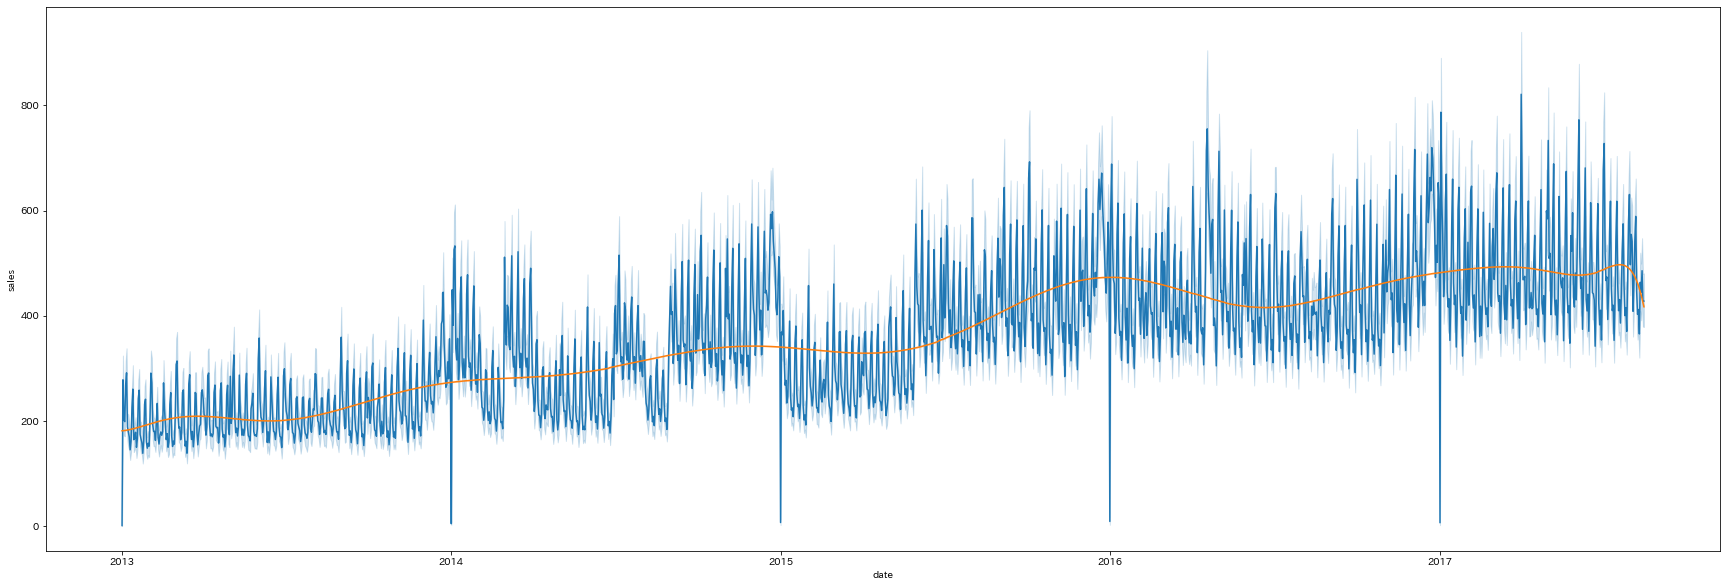

In [16]:

def get_trend(timeseries, deg=24, trainN=0):
    """時系列データのトレンドの線を作成する

    Args:
        timeseries(pd.Series) : 時系列データ。
        deg(int) : 多項式の次数
        trainN(int): 多項式の係数を推定するために使用するデータ数

    Returns:
        pd.Series: トレンドに相当する時系列データ。
    """
    if trainN == 0:
        trainN = len(timeseries)

    x = list(range(len(timeseries)))
    y = timeseries.values
    coef = np.polyfit(x[:trainN], y[:trainN], deg)
    trend = np.poly1d(coef)(x)
    return pd.Series(data=trend, index=timeseries.index)

trainN = 0
#23次元の多項式を使ってとトレンドの線を引いた
train["trend"] = get_trend(train["sales"], trainN=trainN, deg=24)

plt.figure(figsize=(30, 10))
sns.lineplot(x=train["date"], y=train["sales"])
sns.lineplot(x=train["date"], y=train["trend"])

In [17]:
#transactionにnullがある
d=train.query("family==6")
f=d.query("store_nbr==44")
print(f.isnull().sum())

date            0
family          0
onpromotion     0
sales           0
store_nbr       0
city            0
state           0
store_type      0
cluster         0
dcoilwtico      0
transactions    7
holiday_type    0
locale          0
locale_name     0
description     0
transferred     0
ewm_mean        0
年初からの日数%14      0
年初からの日数%28      0
year            0
month           0
week            0
quarter         0
day_of_week     0
trend           0
dtype: int64


In [16]:
# out_fil.index
# DatetimeIndex(['2013-09-01', '2014-08-31', '2014-09-07', '2015-01-01',
#                '2016-01-01', '2016-04-03', '2016-10-02', '2017-01-01'],
#               dtype='datetime64[ns]', name='date', freq=None)

# Out_fil=['2014-08-31', '2014-09-07', '2016-04-03', '2016-10-02']
# f=f[f.date.isin(Out_fil)]

Polyfit may be poorly conditioned

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


<AxesSubplot:xlabel='date', ylabel='sales'>

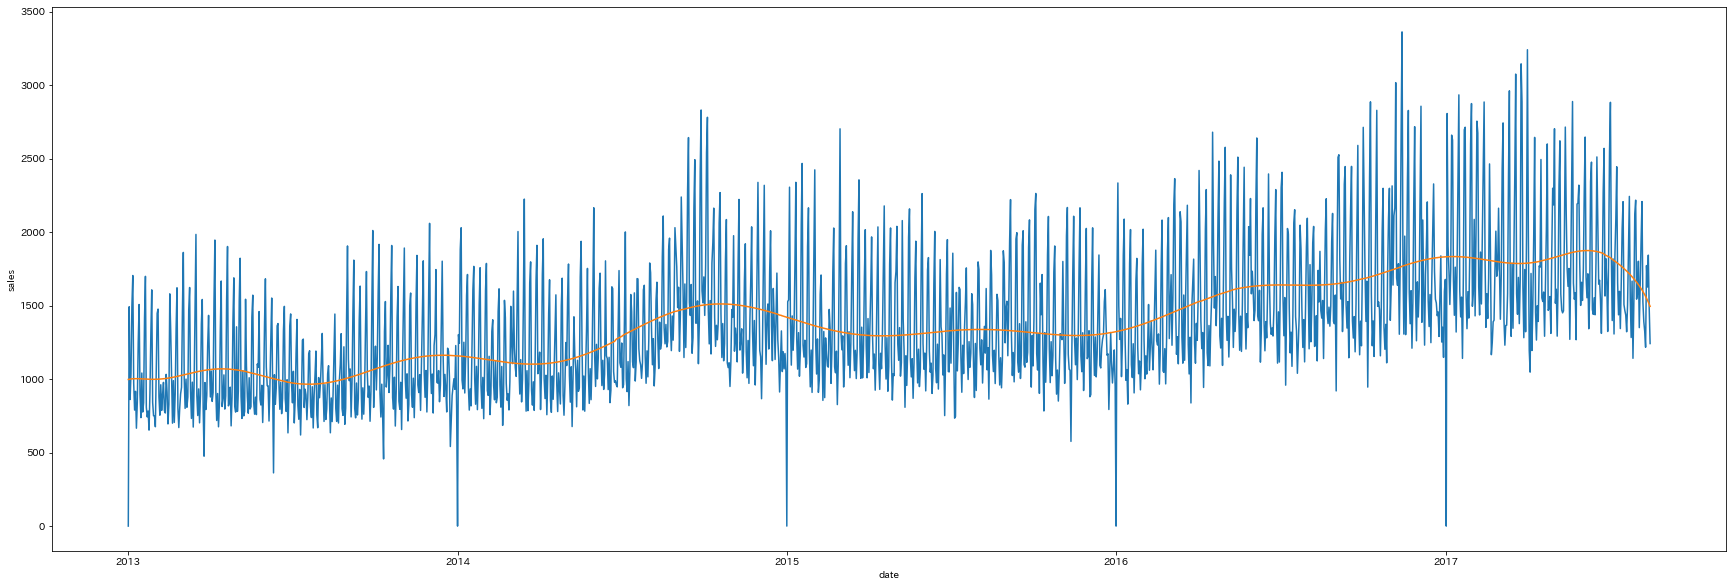

In [18]:
trainN = 0
#24次元の多項式を使ってとトレンドの線を引いた
f["trend"] = get_trend(f["sales"], trainN=trainN, deg=24)

plt.figure(figsize=(30, 10))
sns.lineplot(x=f["date"], y=f["sales"])
sns.lineplot(x=f["date"], y=f["trend"])

In [19]:
train.set_index('date',inplace=True)
test.set_index('date',inplace=True)
f.set_index('date',inplace=True)

In [20]:
features = [feature for feature in train.columns if feature not in ('sales')]

# 1
d=train.query("family==6")
f=d.query("store_nbr==44")

X_446 = f[features].copy()
y_446 = f.sales.copy()

# 2
X = train[features].copy()
y = train.sales.copy()

# 学習データを2013-01-01〜2017-07-31の期間としX_trainに入力する
X_train = X['2013-01-01' : '2017-07-31']
y_train = y['2013-01-01' : '2017-07-31']

# 検証データを2017-08-01以降としてとしてX_validに入力する
X_valid = X['2017-08-01' : ]
y_valid = y['2017-08-01' : ]


X_train_446 = X_446['2013-01-01' : '2017-07-31']
y_train_446 = y_446['2013-01-01' : '2017-07-31']
X_valid_446 = X_446['2017-08-01' : ]
y_valid_446 = y_446['2017-08-01' : ]


X_train_446

,family,onpromotion,store_nbr,city,state,store_type,cluster,dcoilwtico,transactions,holiday_type,...,transferred,ewm_mean,年初からの日数%14,年初からの日数%28,year,month,week,quarter,day_of_week,trend
date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,6,0,44,18,12,0,5,47.26,NaN,3,...,0,0.000013,1,1,2013,1,1,1,5,181.596195
2013-01-02,6,0,44,18,12,0,5,93.14,4821.0,6,...,2,253.641968,2,2,2013,1,1,1,6,181.762952
2013-01-03,6,0,44,18,12,0,5,92.97,3618.0,6,...,2,183.804973,3,3,2013,1,1,1,4,181.962091
2013-01-04,6,0,44,18,12,0,5,93.12,4169.0,6,...,2,198.340931,4,4,2013,1,1,1,0,182.191709
2013-01-05,6,0,44,18,12,0,5,93.12,4921.0,5,...,0,253.068994,5,5,2013,1,1,1,2,182.449963
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-07-27,6,0,44,18,12,0,5,49.05,3801.0,6,...,2,469.314285,12,12,2017,7,30,3,4,493.305704
2017-07-28,6,0,44,18,12,0,5,49.72,4406.0,6,...,2,567.963262,13,13,2017,7,30,3,0,492.084643
2017-07-29,6,0,44,18,12,0,5,49.72,5270.0,6,...,2,790.772583,0,14,2017,7,30,3,2,490.655391


In [21]:
y_train_446

date
2013-01-01       0.000
2013-01-02    1491.913
2013-01-03     861.014
2013-01-04    1037.572
2013-01-05    1496.560
                ...   
2017-07-27    1141.322
2017-07-28    1526.555
2017-07-29    2123.447
2017-07-30    2216.993
2017-07-31    1543.647
Name: sales, Length: 1695, dtype: float64

In [22]:
y_train_446.mean()

1382.5971595103224

In [23]:
y_valid_446.mean()

1597.6064666666668

In [24]:
trend_train, trend_valid = X_train['trend'], X_valid['trend']
trend_train_446, trend_valid_446 = X_train_446['trend'], X_valid_446['trend']

In [25]:
trend_train_446

date
2013-01-01    181.596195
2013-01-02    181.762952
2013-01-03    181.962091
2013-01-04    182.191709
2013-01-05    182.449963
                 ...    
2017-07-27    493.305704
2017-07-28    492.084643
2017-07-29    490.655391
2017-07-30    489.002058
2017-07-31    487.107940
Name: trend, Length: 1695, dtype: float64

In [26]:
trend_valid_446

date
2017-08-01    484.955479
2017-08-02    482.526236
2017-08-03    479.800853
2017-08-04    476.759022
2017-08-05    473.379443
2017-08-06    469.639793
2017-08-07    465.516681
2017-08-08    460.985614
2017-08-09    456.020953
2017-08-10    450.595871
2017-08-11    444.682313
2017-08-12    438.250944
2017-08-13    431.271112
2017-08-14    423.710793
2017-08-15    415.536546
Name: trend, dtype: float64

In [27]:
from sklearn import metrics, ensemble, linear_model
import xgboost as xgb
import catboost as cb
import lightgbm as lgb
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import HistGradientBoostingRegressor
import warnings


Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.


In [28]:

models = {
          '    LGBM': lgb.LGBMRegressor(random_state = 0),
          ' XGBoost': xgb.XGBRegressor(random_state = 0, objective = 'reg:squarederror'),
          'Catboost': cb.CatBoostRegressor(random_state = 0, verbose=False),          
          '    HGBR': HistGradientBoostingRegressor(random_state = 0),
          ' ExtraTr': ensemble.ExtraTreesRegressor(bootstrap = True, random_state = 0),
          ' RandomF': ensemble.RandomForestRegressor(random_state = 0),
         }

In [29]:
from sklearn.metrics import r2_score
def model_evaluation (name, model, models, X_train, y_train, X_valid, y_valid):
   
    rmses = []
    r2s=[]
    mapes=[]
    
    for i in range(len(models)):
    
        # Model fit
        model.fit(X_train, y_train)
        
        # Model predict
        y_preds = model.predict(X_valid)

        # RMSE
        rmse = np.sqrt(np.mean((y_valid - y_preds)**2))
        rmses.append(rmse)

      

        
    # return np.mean(rmses),np.mean(r2s),np.mean(mapes) * 100
    return np.mean(rmses)

4.学習と評価

4.1 Catboost

In [30]:
import catboost as cb
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_log_error
from sklearn.metrics import r2_score

regressor = cb.CatBoostRegressor(random_state = 0, verbose=False).fit(X_train, y_train)
prediction = regressor.predict(X_valid)
def relu(x):
    return np.maximum(0, x) #0とxを比較して大きい方の数値を返す

prediction = relu(prediction)
rmse = np.sqrt(np.mean((y_valid - prediction)**2))
r2=r2_score(y_valid,prediction)


def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_log_error (y_true, y_pred))

rmsle=rmsle(y_valid, prediction)

print(f"誤差(MSE) = {mean_squared_error(y_valid, prediction)}")
print(f"誤差(RMSE) = {rmse}")
print(f"誤差(RMSLE) = {rmsle}")
print(f"誤差(R2) = {r2}")

誤差(MSE) = 45085.657236785395
誤差(RMSE) = 212.3338344136072
誤差(RMSLE) = 1.4609849911194341
誤差(R2) = 0.9708794557479018


In [35]:
#モデルの検証
print(f'train score:{regressor.score(X_train,y_train)}')
print(f'valid score:{regressor.score(X_valid,y_valid)}')

train score:0.9700932451372282
valid score:0.9705494472240532


In [38]:
# regressor_446 = cb.CatBoostRegressor(random_state = 0, verbose=False).fit(X_train_446, y_train_446)
regressor_446 = cb.CatBoostRegressor(random_state = 0, verbose=False).fit(X_train_446, y_train_446,eval_set=(X_valid_446, y_valid_446))
prediction_446 = regressor_446.predict(X_valid_446)

def relu(x):
    return np.maximum(0, x) #0とxを比較して大きい方の数値を返す

prediction_446 = relu(prediction_446)

rmse_446 = np.sqrt(np.mean((y_valid_446 - prediction_446)**2))
# rmsle=np.sqrt(mean_squared_error(np.log1p(y_valid),np.log1p(prediction)))
r2_446=r2_score(y_valid_446,prediction_446)

def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_log_error (y_true, y_pred))

rmsle_446=rmsle(y_valid_446, prediction_446)

print(f"誤差(MSE) = {mean_squared_error(y_valid_446, prediction_446)}")
print(f"誤差(RMSE) = {rmse_446}")
print(f"誤差(RMSLE) = {rmsle_446}")
print(f"誤差(R2) = {r2_446}")

誤差(MSE) = 9343.462005536498
誤差(RMSE) = 96.66158495253684
誤差(RMSLE) = 0.0651286094138247
誤差(R2) = 0.872163276923787


In [39]:
print(f'train score:{regressor_446.score(X_train_446,y_train_446)}')
print(f'valid score:{regressor_446.score(X_valid_446,y_valid_446)}')

train score:0.7872278464207294
valid score:0.872163276923787


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(0.0, 2250.0)

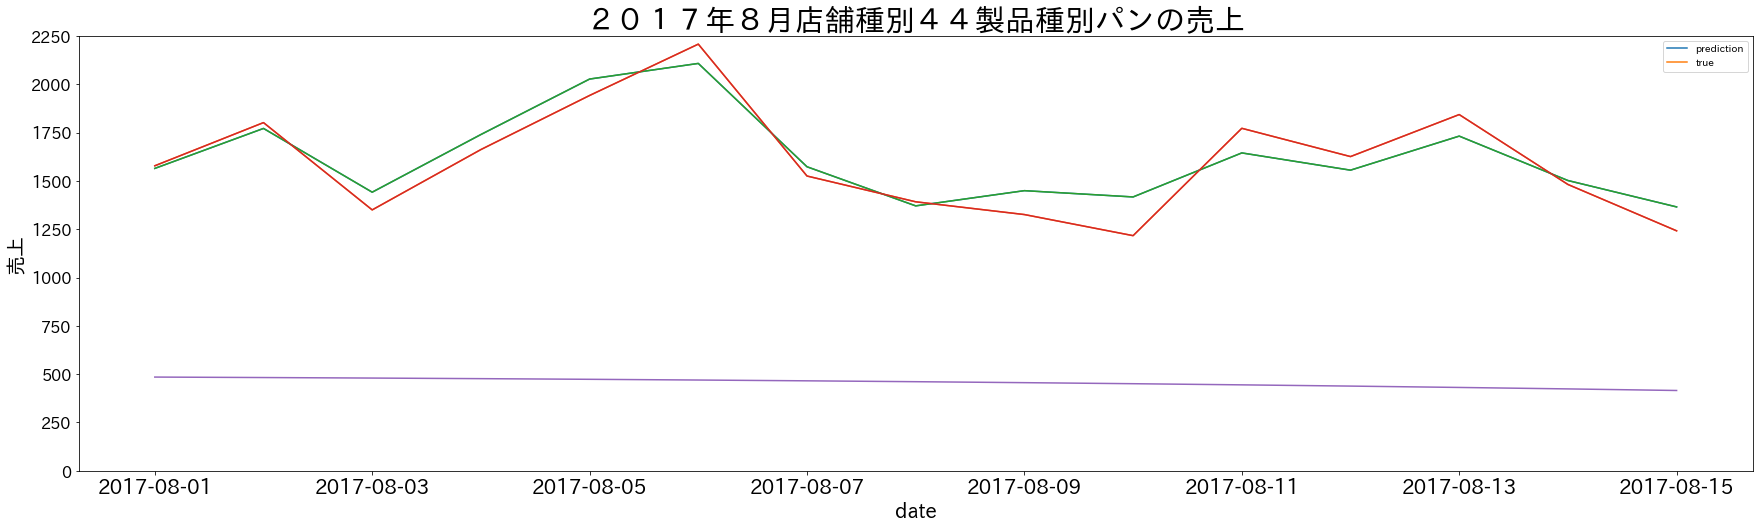

In [40]:
plt.figure(figsize=(30, 8))
plt.title("２０１７年８月店舗種別４４製品種別パンの売上", fontsize=30)

plt.legend( bbox_to_anchor=(0.0, 0.78, 0.28, 0.102),fontsize=40)
plt.xticks(fontsize= 20)
plt.yticks(fontsize= 16)
plt.ylabel('売上', fontsize=20)
plt.xlabel('date', fontsize=20)
sns.lineplot(x=X_valid_446.index, y=prediction_446,label='prediction')
sns.lineplot(x=X_valid_446.index, y=y_valid_446.values,label='true')
sns.lineplot(x=X_valid_446.index, y=prediction_446)
sns.lineplot(x=X_valid_446.index, y=y_valid_446)
sns.lineplot(x=X_valid_446.index, y=trend_valid_446)
plt.ylim(0,2250) #Y軸調整

4.2 LightGBM

[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.106527 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1641
[LightGBM] [Info] Number of data points in the train set: 3020490, number of used features: 23
[LightGBM] [Info] Start training from score 357.544630
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[762]	training's rmse: 226.071	valid_1's rmse: 215.995


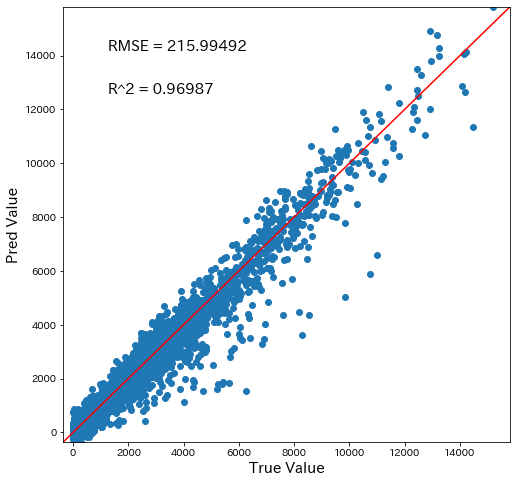

In [36]:
#予測値と正解値を描写する関数
def True_Pred_map(pred_df):
    RMSE = np.sqrt(mean_squared_error(pred_df['true'], pred_df['pred']))
    R2 = r2_score(pred_df['true'], pred_df['pred']) 
    plt.figure(figsize=(8,8))
    ax = plt.subplot(111)
    ax.scatter('true', 'pred', data=pred_df)
    ax.set_xlabel('True Value', fontsize=15)
    ax.set_ylabel('Pred Value', fontsize=15)
    ax.set_xlim(pred_df.min().min()-0.1 , pred_df.max().max()+0.1)
    ax.set_ylim(pred_df.min().min()-0.1 , pred_df.max().max()+0.1)
    x = np.linspace(pred_df.min().min()-0.1, pred_df.max().max()+0.1, 2)
    y = x
    ax.plot(x,y,'r-')
    plt.text(0.1, 0.9, 'RMSE = {}'.format(str(round(RMSE, 5))), transform=ax.transAxes, fontsize=15)
    plt.text(0.1, 0.8, 'R^2 = {}'.format(str(round(R2, 5))), transform=ax.transAxes, fontsize=15)

#Optunaで最適化されたパラメータ
params = {
          "metric": {'rmse'},
          "lambda_l1" : 0.0025266686435780963,
          "lambda_l2" : 0.00036663188229256146,
          "num_leaves" : 19,
          "feature_fraction" : 0.6227761000548198,
          "bagging_fraction" : 0.6306582563386286,
          "bagging_freq" : 4,
          "min_child_samples" : 81,   
        }

trn_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_valid, label=y_valid)
#LightGBMのモデル構築
gbm = lgb.train(params, trn_data, 10000, valid_sets = [trn_data, val_data], verbose_eval=-1, early_stopping_rounds = 10) 
 
#モデル評価用データで予測値出力
predicted = gbm.predict(X_valid)
 
#可視化関数にぶち込めるように予測値と正答値をデータフレームに加工
pred_df = pd.concat([y_valid.reset_index(drop=True), pd.Series(predicted)], axis=1)
pred_df.columns = ['true', 'pred']
 
#可視化関数を実行
True_Pred_map(pred_df)

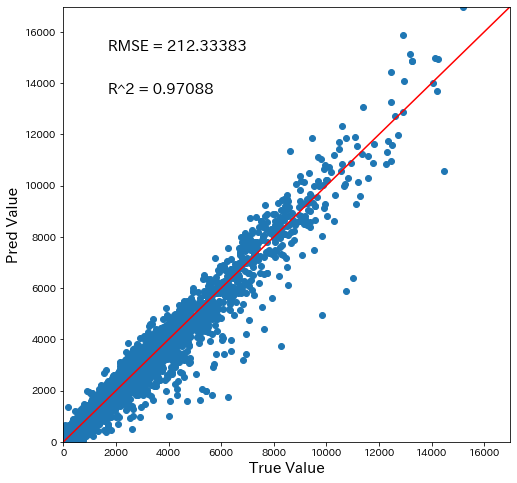

In [37]:
#可視化関数にぶち込めるように予測値と正答値をデータフレームに加工
pred_df = pd.concat([y_valid.reset_index(drop=True), pd.Series(prediction)], axis=1)
pred_df.columns = ['true', 'pred']
 
#可視化関数を実行
True_Pred_map(pred_df)

4.3 Catboost(trend)

誤差(MSE) = 12415.145986641179
誤差(RMSE) = 111.42327398995768
誤差(RMSLE) = 0.07516241468158982
誤差(R2) = 0.830136668987945


<AxesSubplot:title={'center':'２０１７年８月店舗種別４４製品種別パンの売上+trend'}, xlabel='date', ylabel='売上'>

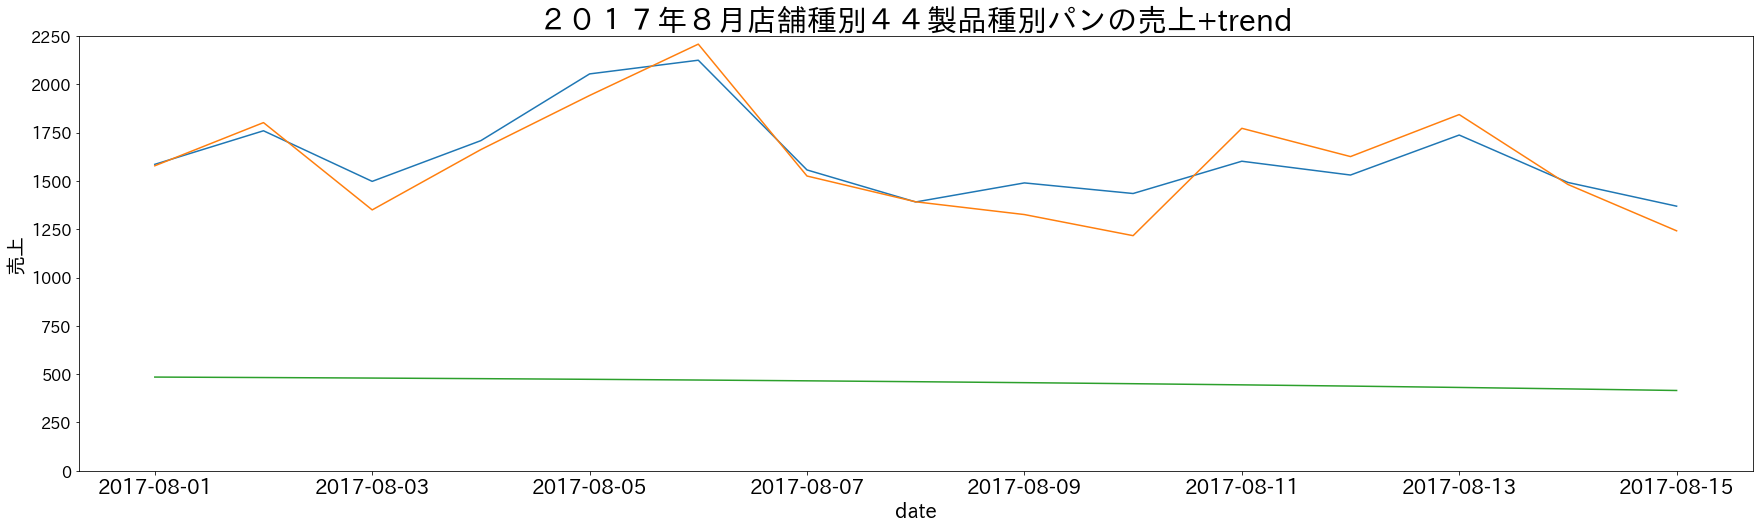

In [43]:
# 先にトレンドに相当する分を観測値から取り除いて、トレンドがない状態の数値を予測します。 その後、トレンドに相当する分を足して最終的な予測値としています。
# regressor_446 = cb.CatBoostRegressor(random_state = 0, verbose=False).fit(X_train_446, y_train_446)
a=y_train_446-trend_train_446
a= relu(a)
b=y_valid_446-trend_valid_446
b= relu(b)

regressor_446 = cb.CatBoostRegressor(random_state = 0, verbose=False).fit(X_train_446, a,eval_set=(X_valid_446, b))
prediction_446 = regressor_446.predict(X_valid_446)


prediction_446 = [pred_i + trend_i for pred_i, trend_i in zip(prediction_446, trend_valid_446)]

def relu(x):
    return np.maximum(0, x) #0とxを比較して大きい方の数値を返す

prediction_446 = relu(prediction_446)
rmse_446 = np.sqrt(np.mean((y_valid_446 - prediction_446)**2))
# rmsle=np.sqrt(mean_squared_error(np.log1p(y_valid),np.log1p(prediction)))
r2_446=r2_score(y_valid_446,prediction_446)



def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_log_error (y_true, y_pred))

rmsle_446=rmsle(y_valid_446, prediction_446)

print(f"誤差(MSE) = {mean_squared_error(y_valid_446, prediction_446)}")
print(f"誤差(RMSE) = {rmse_446}")
print(f"誤差(RMSLE) = {rmsle_446}")
print(f"誤差(R2) = {r2_446}")

plt.figure(figsize=(30, 8))

plt.title("２０１７年８月店舗種別４４製品種別パンの売上+trend", fontsize=30)
plt.xticks(fontsize= 20)
plt.yticks(fontsize= 16)
plt.ylabel('売上', fontsize=20)
plt.xlabel('date', fontsize=20)
plt.ylim(0,2250) #Y軸調整

sns.lineplot(x=X_valid_446.index, y=prediction_446)
sns.lineplot(x=X_valid_446.index, y=y_valid_446)
sns.lineplot(x=X_valid_446.index, y=trend_valid_446)


# 1 ffillbfill(dcol) + 14 28 +trend+ewm_mean+Out_fil
# 誤差(MSE) = 12239.399394297616
# 誤差(RMSE) = 110.63181908609121
# 誤差(RMSLE) = 0.07365439532039135
# 誤差(R2) = 0.8325412240065986

In [44]:
#モデルの検証
#決定係数とは、説明変数が目的変数を良く説明しているかの度合。データがモデルへどのくらい当てはまっているか。
# 予測がどのくらい当たっているかを客観的にしめす指標。回帰分析をした結果、目的変数のばらつき（分散）がどれくらいかを示す。
#同じモデルだが、データセットが異なる
#テスト用データセットの決定係数がとても低くなっている
#訓練データの精度が高く、テストデータの精度が低いことを過学習という
print(f'train score:{regressor_446.score(X_train_446,y_train_446)}')
print(f'valid score:{regressor_446.score(X_valid_446,y_valid_446)}')

train score:0.17496847089583545
valid score:-1.7203528654240396


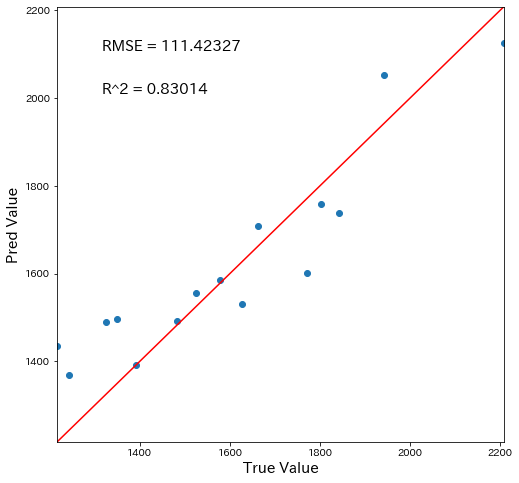

In [42]:
#可視化関数にぶち込めるように予測値と正答値をデータフレームに加工
pred_df = pd.concat([y_valid_446.reset_index(drop=True), pd.Series(prediction_446)], axis=1)
pred_df.columns = ['true', 'pred']
 
#可視化関数を実行
True_Pred_map(pred_df)

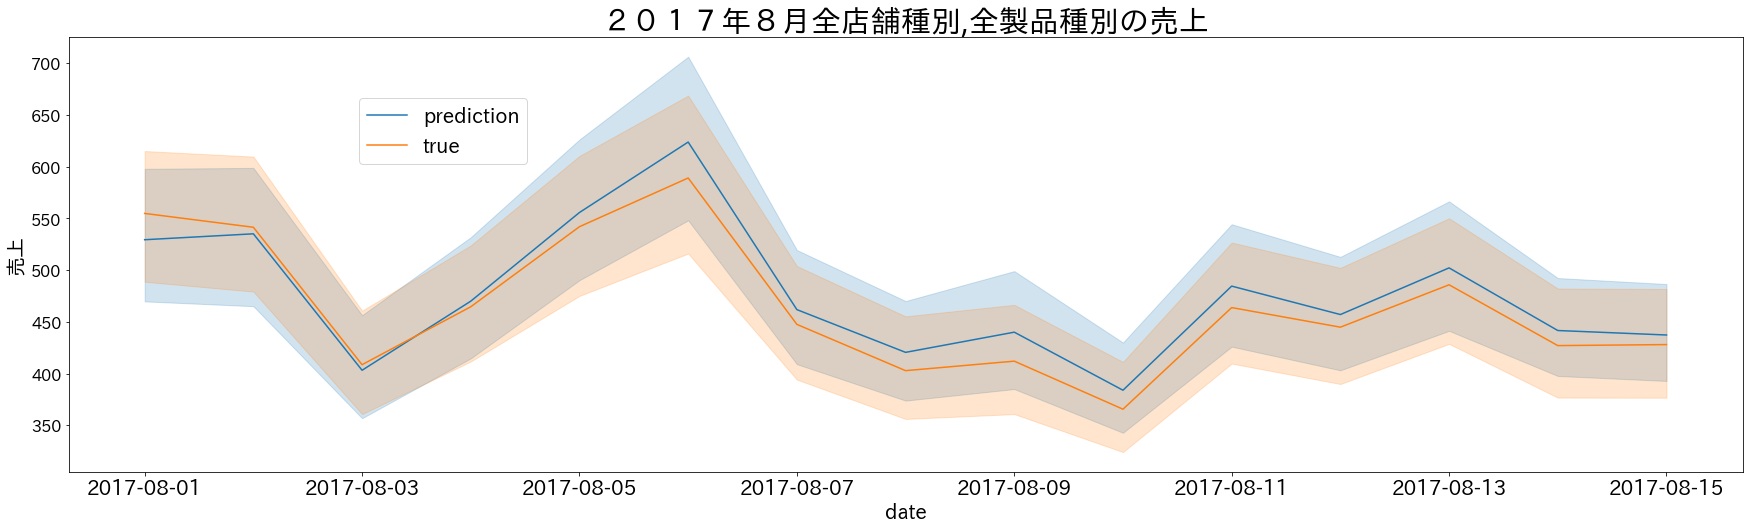

In [47]:
from cProfile import label
a=prediction
b=X_valid.index

plt.figure(figsize=(30, 8))
sns.lineplot(x=b, y=a,label='prediction')
sns.lineplot(x=b, y=y_valid.values,label='true')
# plt.legend(["モデルの出力", "正解"], bbox_to_anchor=(0.0, 0.78, 0.28, 0.102))
# plt.title("２０１７年８月店舗種別４４製品種別パンの売上", fontsize=30)
plt.title("２０１７年８月全店舗種別,全製品種別の売上", fontsize=30)
plt.xticks(fontsize= 20)
plt.yticks(fontsize= 16)
plt.ylabel('売上', fontsize=20)
plt.xlabel('date', fontsize=20)
plt.legend( bbox_to_anchor=(0.0, 0.78, 0.28, 0.102),fontsize=20)
plt.show()

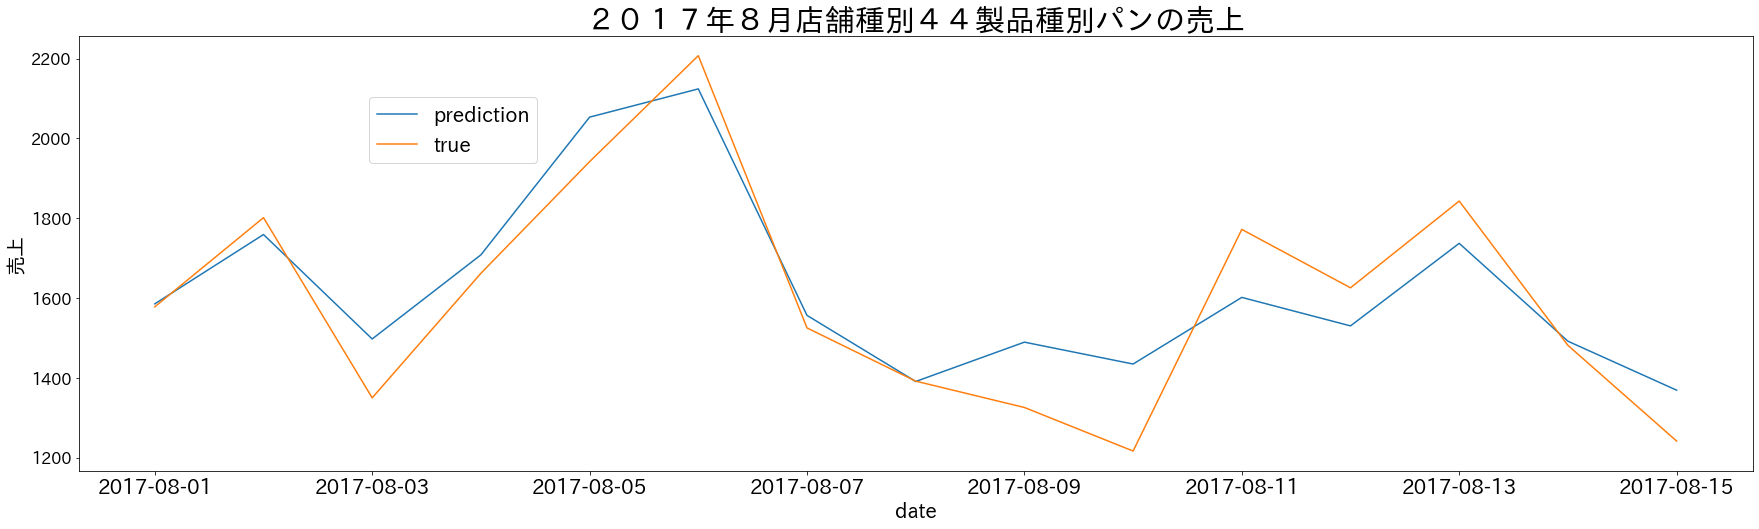

In [48]:
from cProfile import label
g=prediction_446
h=X_valid_446.index

plt.figure(figsize=(30, 8))
sns.lineplot(x=h, y=g,label='prediction')
sns.lineplot(x=h, y=y_valid_446.values,label='true')
# plt.legend(["モデルの出力", "正解"], bbox_to_anchor=(0.0, 0.78, 0.28, 0.102))
plt.title("２０１７年８月店舗種別４４製品種別パンの売上", fontsize=30)
# plt.title("２０１７年８月の売上", fontsize=30)
plt.xticks(fontsize= 20)
plt.yticks(fontsize= 16)
plt.ylabel('売上', fontsize=20)
plt.xlabel('date', fontsize=20)
plt.legend( bbox_to_anchor=(0.0, 0.78, 0.28, 0.102),fontsize=20)
plt.show()

In [49]:
f_median = f.median()
f_ewm_mean = f['sales'].ewm(span=90).mean()  
# f = f.fillna(method='ffill')
f = f.fillna(f_ewm_mean)
f.dropna()
X_446 = f[features].copy()
y_446 = f.sales.copy()

X_train_446 = X_446['2013-01-01' : '2017-07-31']
y_train_446 = y_446['2013-01-01' : '2017-07-31']
X_valid_446 = X_446['2017-08-01' : ]
y_valid_446 = y_446['2017-08-01' : ]

In [50]:
print(X_446.isnull().values.sum())

7


In [51]:
print(y_446.isnull().values.sum())

0


In [52]:
print(X_446[X_446.isnull().any(axis=1)])

            family  onpromotion  store_nbr  city  state  store_type  cluster  \
date                                                                           
2013-01-01       6            0         44    18     12           0        5   
2014-01-01       6            0         44    18     12           0        5   
2015-01-01       6            0         44    18     12           0        5   
2016-01-01       6            0         44    18     12           0        5   
2016-01-03       6            0         44    18     12           0        5   
2016-01-04       6            0         44    18     12           0        5   
2017-01-01       6            0         44    18     12           0        5   

            dcoilwtico  transactions  holiday_type  ...  transferred  \
date                                                ...                
2013-01-01       47.26           NaN             3  ...            0   
2014-01-01       98.17           NaN             3  ...        

In [53]:
Out_fil=['2013-01-01', '2014-01-01', '2015-01-01', '2016-01-01','2016-01-03','2016-01-04','2017-01-01']
f=f[~f.index.isin(Out_fil)]
X_446 = f[features].copy()
y_446 = f.sales.copy()

X_train_446 = X_446['2013-01-02' : '2017-07-31']
y_train_446 = y_446['2013-01-02' : '2017-07-31']
X_valid_446 = X_446['2017-08-01' : ]
y_valid_446 = y_446['2017-08-01' : ]

In [54]:
print(X_446[X_446.isnull().any(axis=1)])

Empty DataFrame
Columns: [family, onpromotion, store_nbr, city, state, store_type, cluster, dcoilwtico, transactions, holiday_type, locale, locale_name, description, transferred, ewm_mean, 年初からの日数%14, 年初からの日数%28, year, month, week, quarter, day_of_week, trend]
Index: []

[0 rows x 23 columns]


4.4 UMAP

In [55]:
# UMAP
import umap.umap_ as umap
embedding = umap.UMAP(n_components=2, random_state=0)
# embedding = umap.UMAP(n_components=2, n_neighbors=15, random_state=0)
X_reduced_umap = embedding.fit_transform(X_446)
print(X_reduced_umap.shape) # (470, 2)


date_index=X_446.index
# index_446=index_446.astype('object')
# index_446=pd.to_datetime(index_446,format='%Y年%m月%d日')
# index_446
xx=pd.DataFrame(data=X_reduced_umap,index=date_index)


X_tsne_train_446 = xx['2013-01-01' : '2017-07-31']
y_train_446 = y_446['2013-01-01' : '2017-07-31']
X_tsne_valid_446 = xx['2017-08-01' : ]
y_valid_446 = y_446['2017-08-01' : ]

# regressor_446 = cb.CatBoostRegressor(random_state = 0, verbose=False).fit(X_train_446, y_train_446)
regressor_446 = cb.CatBoostRegressor(random_state = 0, verbose=False).fit(X_tsne_train_446, y_train_446,eval_set=(X_tsne_valid_446, y_valid_446))
prediction_446 = regressor_446.predict(X_tsne_valid_446)

def relu(x):
    return np.maximum(0, x) #0とxを比較して大きい方の数値を返す

prediction_446 = relu(prediction_446)
rmse_446 = np.sqrt(np.mean((y_valid_446 - prediction_446)**2))
# rmsle=np.sqrt(mean_squared_error(np.log1p(y_valid),np.log1p(prediction)))
r2_446=r2_score(y_valid_446,prediction_446)


def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_log_error (y_true, y_pred))

rmsle_446=rmsle(y_valid_446, prediction_446)

print(f"誤差(MSE) = {mean_squared_error(y_valid_446, prediction_446)}")
print(f"誤差(RMSE) = {rmse_446}")
print(f"誤差(RMSLE) = {rmsle_446}")
print(f"誤差(R2) = {r2_446}")

regressor_446.fit(X_train_446, y_train_446)
print(f'train score:{regressor_446.score(X_train_446,y_train_446)}')
print(f'valid score:{regressor_446.score(X_valid_446,y_valid_446)}')

(1703, 2)
誤差(MSE) = 9422.488522945834
誤差(RMSE) = 97.06950356804053
誤差(RMSLE) = 0.06211106952281092
誤差(R2) = 0.8710820405452638
train score:0.9877459380599849
valid score:0.6103334369836839


4.5 PCA

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.


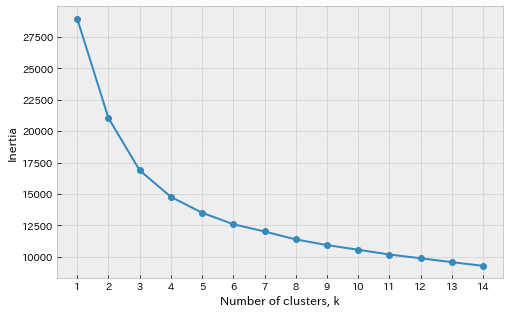

In [56]:
# PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
scaler = StandardScaler()
scaler.fit(X_446)
x = scaler.transform(X_446)

from sklearn.cluster import KMeans 
#check the optimal k value
ks = range(1, 15)
inertias = []

for k in ks:
    model = KMeans(n_clusters=k)
    model.fit(x)
    inertias.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.style.use('bmh')
plt.plot(ks, inertias, '-o')
plt.xlabel('Number of clusters, k')
plt.ylabel('Inertia')
plt.xticks(ks)
plt.show()

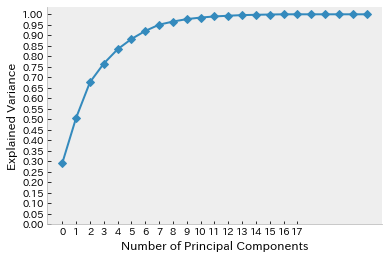

In [57]:
pca = PCA()
comp = pca.fit(x)
cumsum=np.cumsum(comp.explained_variance_ratio_)
# We plot a graph to show how the explained variation in the 129 features varies with the number of principal components
plt.plot(cumsum,'D-')
plt.grid()
plt.xticks(range(18))
plt.yticks(np.arange(0,1.05,0.05))
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance')
sns.despine();

In [58]:
dim = np.argmax(cumsum >= 0.90) + 1
print('The number of dimensions required to preserve 90% of variance is',dim)

The number of dimensions required to preserve 90% of variance is 7


In [59]:
# Using the first 50 principal components, we apply the PCA mapping on both the training and test set
pca = PCA(n_components=7).fit(x)
x = pca.transform(x)
date_index=X_446.index
# index_446=index_446.astype('object')
# index_446=pd.to_datetime(index_446,format='%Y年%m月%d日')
# index_446
xx=pd.DataFrame(data=x,index=date_index)


X_pca_train_446 = xx['2013-01-01' : '2017-07-31']
y_train_446 = y_446['2013-01-01' : '2017-07-31']
X_pca_valid_446 = xx['2017-08-01' : ]
y_valid_446 = y_446['2017-08-01' : ]
# regressor_446 = cb.CatBoostRegressor(random_state = 0, verbose=False).fit(X_train_446, y_train_446)
regressor_446 = cb.CatBoostRegressor(random_state = 0, verbose=False).fit(X_pca_train_446, y_train_446,eval_set=(X_pca_valid_446, y_valid_446))
prediction_446 = regressor_446.predict(X_pca_valid_446)

def relu(x):
    return np.maximum(0, x) #0とxを比較して大きい方の数値を返す

prediction_446 = relu(prediction_446)
rmse_446 = np.sqrt(np.mean((y_valid_446 - prediction_446)**2))
# rmsle=np.sqrt(mean_squared_error(np.log1p(y_valid),np.log1p(prediction)))
r2_446=r2_score(y_valid_446,prediction_446)


def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_log_error (y_true, y_pred))

rmsle_446=rmsle(y_valid_446, prediction_446)

print(f"誤差(MSE) = {mean_squared_error(y_valid_446, prediction_446)}")
print(f"誤差(RMSE) = {rmse_446}")
print(f"誤差(RMSLE) = {rmsle_446}")
print(f"誤差(R2) = {r2_446}")

#PCA median
#  誤差(MSE) = 18983.040033702513
# 誤差(RMSE) = 137.77895352230874
# 誤差(RMSLE) = 0.0912555692450067
# 誤差(R2) = 0.740275111035382

#誤差(MSE) = 24971.618183616534
# 誤差(RMSE) = 158.02410633702866
# 誤差(RMSLE) = 0.10472300042439753
# 誤差(R2) = 0.6583397206932173
# train score:0.9765826495143998
# valid score:0.4767753999929466

# 誤差(MSE) = 38257.56679694362
# 誤差(RMSE) = 195.59541609389424
# 誤差(RMSLE) = 0.12169494661516872
# 誤差(R2) = 0.4765621169869808
# train score:0.9797025927043165
# valid score:0.4959000450431824

#dropnaOut_fil=['2013-01-01', '2014-01-01', '2015-01-01', '2016-01-01','2016-01-03','2016-01-04','2017-01-01']
# 誤差(MSE) = 38763.05337983012
# 誤差(RMSE) = 196.8833496764775
# 誤差(RMSLE) = 0.12310114527996656
# 誤差(R2) = 0.4696460779131437

誤差(MSE) = 38763.05337983012
誤差(RMSE) = 196.8833496764775
誤差(RMSLE) = 0.12310114527996656
誤差(R2) = 0.4696460779131437


4.6 PCA&UMAP

In [60]:
# PCA & UMAP

# PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=6)
PC = pca.fit_transform(X_446)
print(PC.shape)

# UMAP
import umap.umap_ as umap
embedding = umap.UMAP(n_components=2,random_state=0)
X_reduced_pca_umap = embedding.fit_transform(PC)


date_index=X_446.index
# index_446=index_446.astype('object')
# index_446=pd.to_datetime(index_446,format='%Y年%m月%d日')
# index_446
xx=pd.DataFrame(data=X_reduced_pca_umap,index=date_index)


X_pca_train_446 = xx['2013-01-01' : '2017-07-31']
y_train_446 = y_446['2013-01-01' : '2017-07-31']
X_pca_valid_446 = xx['2017-08-01' : ]
y_valid_446 = y_446['2017-08-01' : ]
# regressor_446 = cb.CatBoostRegressor(random_state = 0, verbose=False).fit(X_train_446, y_train_446)
regressor_446 = cb.CatBoostRegressor(random_state = 0, verbose=False).fit(X_pca_train_446, y_train_446,eval_set=(X_pca_valid_446, y_valid_446))
prediction_446 = regressor_446.predict(X_pca_valid_446)

def relu(x):
    return np.maximum(0, x) #0とxを比較して大きい方の数値を返す

prediction_446_pca_umap = relu(prediction_446)
rmse_446 = np.sqrt(np.mean((y_valid_446 - prediction_446_pca_umap)**2))
# rmsle=np.sqrt(mean_squared_error(np.log1p(y_valid),np.log1p(prediction)))
r2_446=r2_score(y_valid_446,prediction_446_pca_umap)


def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_log_error (y_true, y_pred))

rmsle_446=rmsle(y_valid_446, prediction_446_pca_umap)

print(f"誤差(MSE) = {mean_squared_error(y_valid_446, prediction_446_pca_umap)}")
print(f"誤差(RMSE) = {rmse_446}")
print(f"誤差(RMSLE) = {rmsle_446}")
print(f"誤差(R2) = {r2_446}")

(1703, 6)
誤差(MSE) = 7271.420932612793
誤差(RMSE) = 85.27262710045231
誤差(RMSLE) = 0.055469460258949166
誤差(R2) = 0.9005128266608041


In [61]:
print(f'train score:{regressor_446.score(X_pca_train_446,y_train_446)}')
print(f'valid score:{regressor_446.score(X_pca_valid_446,y_valid_446)}')

train score:0.9010755190822365
valid score:0.9005128266608041


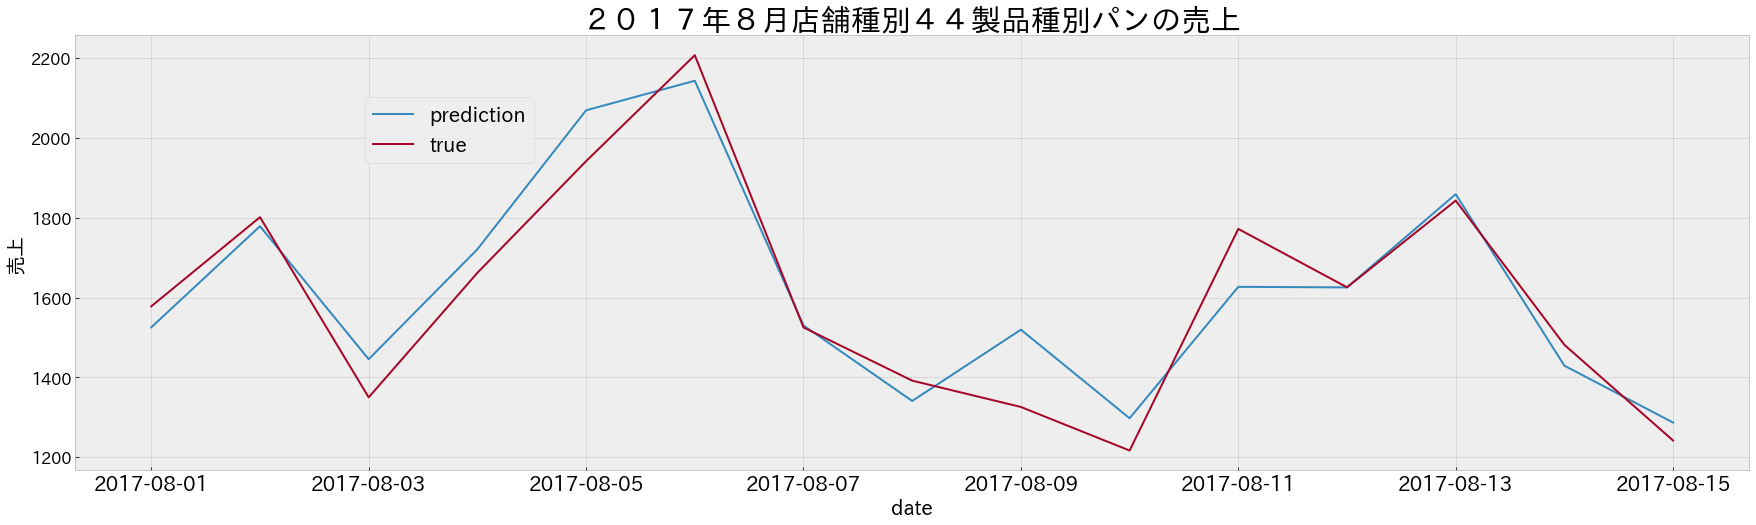

In [63]:
from cProfile import label
g=prediction_446
h=X_valid_446.index

plt.figure(figsize=(30, 8))
sns.lineplot(x=h, y=g,label='prediction')
sns.lineplot(x=h, y=y_valid_446.values,label='true')
# plt.legend(["モデルの出力", "正解"], bbox_to_anchor=(0.0, 0.78, 0.28, 0.102))
plt.title("２０１７年８月店舗種別４４製品種別パンの売上", fontsize=30)
# plt.title("２０１７年８月の売上", fontsize=30)
plt.xticks(fontsize= 20)
plt.yticks(fontsize= 16)
plt.ylabel('売上', fontsize=20)
plt.xlabel('date', fontsize=20)
plt.legend( bbox_to_anchor=(0.0, 0.78, 0.28, 0.102),fontsize=20)
plt.show()

C:\Users\PCHNe\AppData\Local\Temp\ipykernel_26304\1462632406.py:6: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


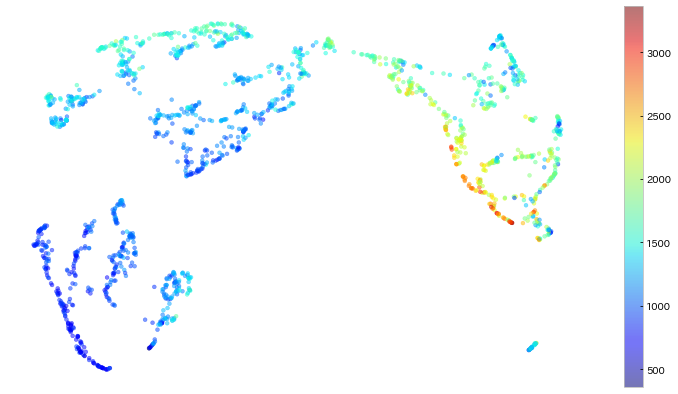

In [64]:
plt.figure(figsize=(13, 7))
plt.scatter(X_reduced_pca_umap[:, 0], X_reduced_pca_umap[:, 1],
            c=y_446, cmap='jet',
            s=15, alpha=0.5)
plt.axis('off')
plt.colorbar()
plt.show()

In [65]:
regressor_446.fit(X_train_446, y_train_446)
print(f'train score:{regressor_446.score(X_train_446,y_train_446)}')
print(f'valid score:{regressor_446.score(X_valid_446,y_valid_446)}')

train score:0.9877459380599849
valid score:0.6103334369836839


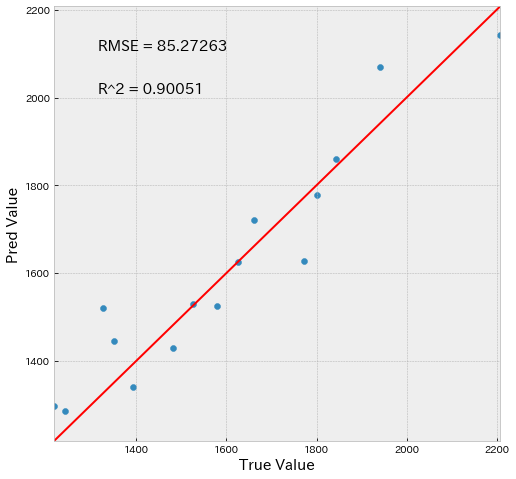

In [66]:
#可視化関数にぶち込めるように予測値と正答値をデータフレームに加工
pred_df = pd.concat([y_valid_446.reset_index(drop=True), pd.Series(prediction_446)], axis=1)
pred_df.columns = ['true', 'pred']
 
#可視化関数を実行
True_Pred_map(pred_df)

4.7 PCA&UMAP+trend

In [62]:
# # PCA & UMAP+trend

# # PCA
# from sklearn.decomposition import PCA
# pca = PCA(n_components=6)
# PC = pca.fit_transform(X_446)
# print(PC.shape)

# # UMAP
# import umap.umap_ as umap
# embedding = umap.UMAP(n_components=2,random_state=0)
# X_reduced_pca_umap = embedding.fit_transform(PC)


# date_index=X_446.index
# # index_446=index_446.astype('object')
# # index_446=pd.to_datetime(index_446,format='%Y年%m月%d日')
# # index_446
# xx=pd.DataFrame(data=X_reduced_pca_umap,index=date_index)


# X_pca_train_446 = xx['2013-01-01' : '2017-07-31']
# y_train_446 = y_446['2013-01-01' : '2017-07-31']
# X_pca_valid_446 = xx['2017-08-01' : ]
# y_valid_446 = y_446['2017-08-01' : ]

# trend_train_446, trend_valid_446 = X_train_446['trend'], X_valid_446['trend']
# # X_tsne_train_446.drop('trend',axis=1,inplace=True)
# # X_tsne_valid_446.drop('trend',axis=1,inplace=True)

# # 先にトレンドに相当する分を観測値から取り除いて、トレンドがない状態の数値を予測します。 その後、トレンドに相当する分を足して最終的な予測値としています。
# # regressor_446 = cb.CatBoostRegressor(random_state = 0, verbose=False).fit(X_train_446, y_train_446)
# a=y_train_446-trend_train_446
# a= relu(a)
# b=y_valid_446-trend_valid_446
# b= relu(b)

# regressor_446 = cb.CatBoostRegressor(random_state = 0, verbose=False).fit(X_pca_train_446, a,eval_set=(X_pca_valid_446, b))
# prediction_446 = regressor_446.predict(X_pca_valid_446)


# prediction_446 = [pred_i + trend_i for pred_i, trend_i in zip(prediction_446, trend_valid_446*0.985)]

# def relu(x):
#     return np.maximum(0, x) #0とxを比較して大きい方の数値を返す

# prediction_446 = relu(prediction_446)
# rmse_446 = np.sqrt(np.mean((y_valid_446 - prediction_446)**2))
# # rmsle=np.sqrt(mean_squared_error(np.log1p(y_valid),np.log1p(prediction)))
# r2_446=r2_score(y_valid_446,prediction_446)



# def rmsle(y_true, y_pred):
#     return np.sqrt(mean_squared_log_error (y_true, y_pred))

# rmsle_446=rmsle(y_valid_446, prediction_446)

# print(f"誤差(MSE) = {mean_squared_error(y_valid_446, prediction_446)}")
# print(f"誤差(RMSE) = {rmse_446}")
# print(f"誤差(RMSLE) = {rmsle_446}")
# print(f"誤差(R2) = {r2_446}")

# plt.figure(figsize=(30, 8))
# plt.title("２０１７年８月店舗種別４４製品種別パンの売上", fontsize=30)
# plt.xticks(fontsize= 20)
# plt.yticks(fontsize= 16)
# plt.ylabel('売上', fontsize=20)
# plt.xlabel('date', fontsize=20)
# # plt.legend( bbox_to_anchor=(0.0, 0.78, 0.28, 0.102),fontsize=20)
# # sns.lineplot(x=b, y=a,label='prediction')
# # sns.lineplot(x=b, y=y_valid.values,label='true')
# sns.lineplot(x=X_valid_446.index, y=prediction_446)
# sns.lineplot(x=X_valid_446.index, y=y_valid_446)

4.8 t-SNE

In [68]:
# t-SNE
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=0)
X_reduced_tsne = tsne.fit_transform(X_446)

date_index=X_446.index
# index_446=index_446.astype('object')
# index_446=pd.to_datetime(index_446,format='%Y年%m月%d日')
# index_446
xx=pd.DataFrame(data=X_reduced_tsne,index=date_index)


X_tsne_train_446 = xx['2013-01-01' : '2017-07-31']
y_train_446 = y_446['2013-01-01' : '2017-07-31']
X_tsne_valid_446 = xx['2017-08-01' : ]
y_valid_446 = y_446['2017-08-01' : ]

# regressor_446 = cb.CatBoostRegressor(random_state = 0, verbose=False).fit(X_train_446, y_train_446)
regressor_446 = cb.CatBoostRegressor(random_state = 0, verbose=False).fit(X_tsne_train_446, y_train_446,eval_set=(X_tsne_valid_446, y_valid_446))
prediction_446 = regressor_446.predict(X_tsne_valid_446)

def relu(x):
    return np.maximum(0, x) #0とxを比較して大きい方の数値を返す

prediction_446 = relu(prediction_446)
rmse_446 = np.sqrt(np.mean((y_valid_446 - prediction_446)**2))
# rmsle=np.sqrt(mean_squared_error(np.log1p(y_valid),np.log1p(prediction)))
r2_446=r2_score(y_valid_446,prediction_446)


def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_log_error (y_true, y_pred))

rmsle_446=rmsle(y_valid_446, prediction_446)

print(f"誤差(MSE) = {mean_squared_error(y_valid_446, prediction_446)}")
print(f"誤差(RMSE) = {rmse_446}")
print(f"誤差(RMSLE) = {rmsle_446}")
print(f"誤差(R2) = {r2_446}")

regressor_446.fit(X_train_446, y_train_446)
print(f'train score:{regressor_446.score(X_train_446,y_train_446)}')
print(f'valid score:{regressor_446.score(X_valid_446,y_valid_446)}')

#tsne median
# 誤差(MSE) = 25177.259923730402
# 誤差(RMSE) = 158.67343799051687
# 誤差(RMSLE) = 0.10127793945313404
# 誤差(R2) = 0.6555261419396172
# train score:0.8536882089291502
# valid score:0.546400674555193



# 1 ffillbfill(dcol) + 14 28 +trend+ewm_mean+Out_fil
# 誤差(MSE) = 7981.537957759821
# 誤差(RMSE) = 89.339453534034(main89.4361917199617)
# 誤差(RMSLE) = 0.06300095058943664
# 誤差(R2) = 0.8907970453538717
# train score:0.8969951044178219
# valid score:0.859915901507154


# 1 ffillbfill(dcol) + 14 28 +trend+ewm_mean+Out_fil+dropnaOut_fil=['2013-01-01', '2014-01-01', '2015-01-01', '2016-01-01','2016-01-03','2016-01-04','2017-01-01']
# 誤差(MSE) = 7699.146314205215
# 誤差(RMSE) = 87.74477941282441
# 誤差(RMSLE) = 0.061786148523286746
# 誤差(R2) = 0.894660711981374
# train score:0.9877459380599849
# valid score:0.6103334369836839

c:\Users\PCHNe\anaconda3\envs\c\lib\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
c:\Users\PCHNe\anaconda3\envs\c\lib\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


誤差(MSE) = 7699.146314205215
誤差(RMSE) = 87.74477941282441
誤差(RMSLE) = 0.061786148523286746
誤差(R2) = 0.894660711981374
train score:0.9877459380599849
valid score:0.6103334369836839


In [73]:
print(f'train score:{regressor_446.score(X_tsne_train_446,y_train_446)}')
print(f'valid score:{regressor_446.score(X_tsne_valid_446,y_valid_446)}')

train score:0.303347676133494
valid score:-1.462285500577504


C:\Users\PCHNe\AppData\Local\Temp\ipykernel_23308\503394738.py:6: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


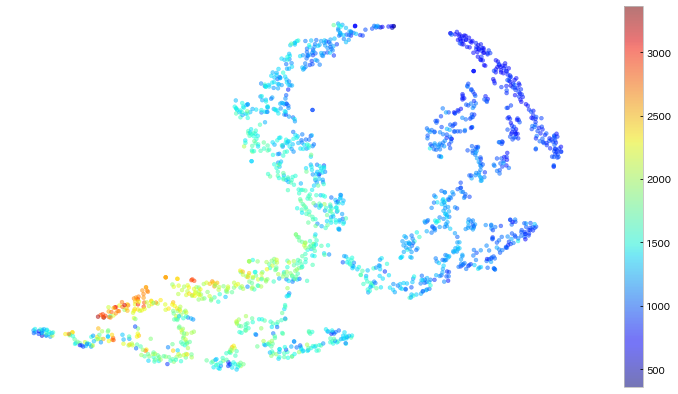

In [ ]:
plt.figure(figsize=(13, 7))
plt.scatter(X_reduced_tsne[:, 0], X_reduced_tsne[:, 1],
            c=y_446, cmap='jet',
            s=15, alpha=0.5)
plt.axis('off')
plt.colorbar()
plt.show()

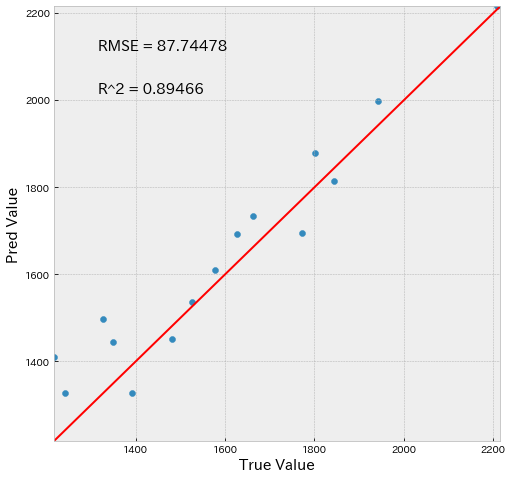

In [ ]:
#可視化関数に入れ込めるように予測値と正答値をデータフレームに加工
pred_df = pd.concat([y_valid_446.reset_index(drop=True), pd.Series(prediction_446)], axis=1)
pred_df.columns = ['true', 'pred']
 
#可視化関数を実行
True_Pred_map(pred_df)

In [ ]:
X_valid_446

,family,onpromotion,store_nbr,city,state,store_type,cluster,dcoilwtico,transactions,holiday_type,locale,locale_name,description,transferred,ewm_mean,年初からの日数%14,年初からの日数%28,year,month,week,quarter,day_of_week,trend
date,,,,,,,,,,,,,,,,,,,,,,,
2017-08-01,6,0,44,18,12,0,5,49.19,4063.0,6,3,24,101,2,695.333350,3,17,2017,8,31,3,5,484.955479
2017-08-02,6,0,44,18,12,0,5,49.60,4643.0,6,3,24,101,2,636.418907,4,18,2017,8,31,3,6,482.526236
2017-08-03,6,11,44,18,12,0,5,49.03,4169.0,6,3,24,101,2,472.293880,5,19,2017,8,31,3,4,479.800853
2017-08-04,6,12,44,18,12,0,5,49.57,4515.0,6,3,24,101,2,604.379139,6,20,2017,8,31,3,0,476.759022
2017-08-05,6,11,44,18,12,0,5,49.57,5037.0,3,0,6,19,0,656.910379,7,21,2017,8,31,3,2,473.379443
2017-08-06,6,11,44,18,12,0,5,49.57,5015.0,6,3,24,101,2,745.051039,8,22,2017,8,31,3,3,469.639793
2017-08-07,6,9,44,18,12,0,5,49.37,4049.0,6,3,24,101,2,573.501908,9,23,2017,8,32,3,1,465.516681
2017-08-08,6,10,44,18,12,0,5,49.07,3690.0,6,3,24,101,2,519.438277,10,24,2017,8,32,3,5,460.985614
2017-08-09,6,11,44,18,12,0,5,49.59,4239.0,6,3,24,101,2,499.023394,11,25,2017,8,32,3,6,456.020953


4.9 t-SNE+trend

c:\Users\PCHNe\anaconda3\envs\c\lib\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
c:\Users\PCHNe\anaconda3\envs\c\lib\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


誤差(MSE) = 7553.21044300699
誤差(RMSE) = 86.9092080449879
誤差(RMSLE) = 0.059897521661051834
誤差(R2) = 0.8966573983854284


<AxesSubplot:title={'center':'２０１７年８月店舗種別４４製品種別パンの売上+trend'}, xlabel='date', ylabel='売上'>

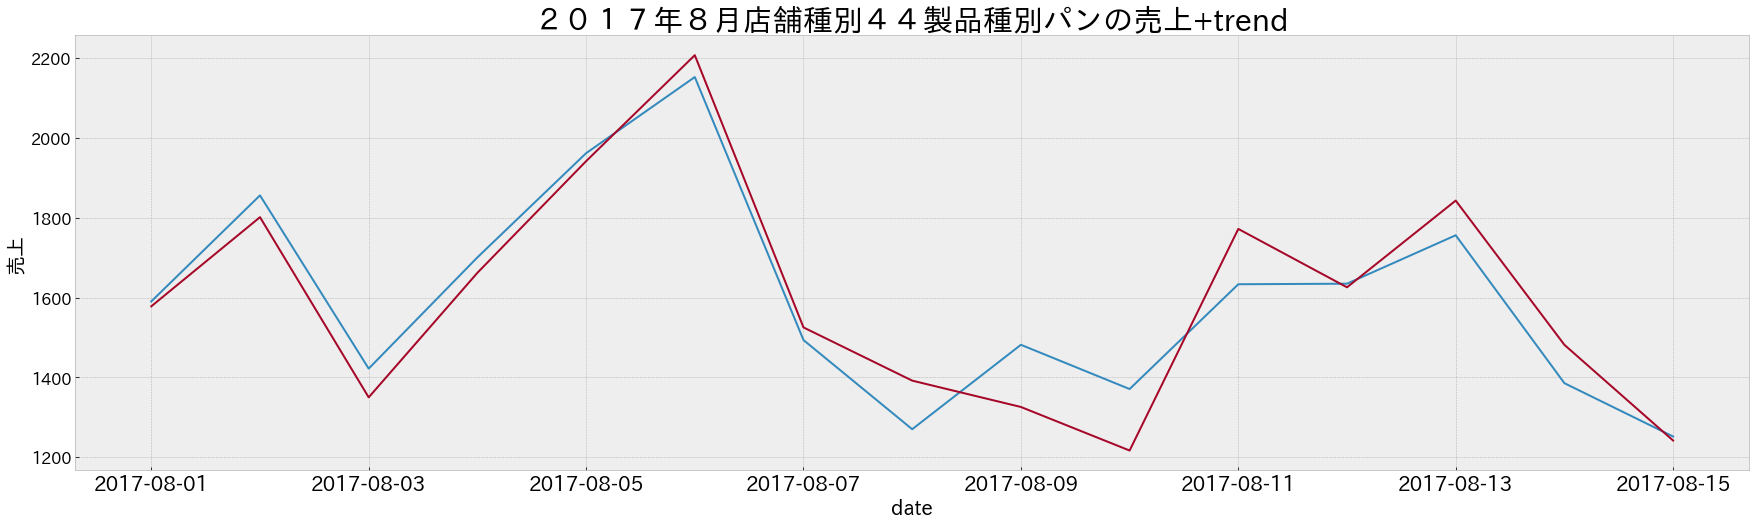

In [70]:
# t-SNE+trend
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=0)
X_reduced_tsne = tsne.fit_transform(X_446)

date_index=X_446.index
# index_446=index_446.astype('object')
# index_446=pd.to_datetime(index_446,format='%Y年%m月%d日')
# index_446
xx=pd.DataFrame(data=X_reduced_tsne,index=date_index)


X_tsne_train_446 = xx['2013-01-01' : '2017-07-31']
y_train_446 = y_446['2013-01-01' : '2017-07-31']
X_tsne_valid_446 = xx['2017-08-01' : ]
y_valid_446 = y_446['2017-08-01' : ]

trend_train_446, trend_valid_446 = X_train_446['trend'], X_valid_446['trend']
# X_tsne_train_446.drop('trend',axis=1,inplace=True)
# X_tsne_valid_446.drop('trend',axis=1,inplace=True)

# 先にトレンドに相当する分を観測値から取り除いて、トレンドがない状態の数値を予測します。 その後、トレンドに相当する分を足して最終的な予測値としています。
# regressor_446 = cb.CatBoostRegressor(random_state = 0, verbose=False).fit(X_train_446, y_train_446)
a=y_train_446-trend_train_446
a= relu(a)
b=y_valid_446-trend_valid_446
b= relu(b)

regressor_446 = cb.CatBoostRegressor(random_state = 0, verbose=False).fit(X_tsne_train_446, a,eval_set=(X_tsne_valid_446, b))
prediction_446 = regressor_446.predict(X_tsne_valid_446)


prediction_446 = [pred_i + trend_i for pred_i, trend_i in zip(prediction_446, trend_valid_446*0.91)]

def relu(x):
    return np.maximum(0, x) #0とxを比較して大きい方の数値を返す

prediction_446_tsne_trend = relu(prediction_446)
rmse_446 = np.sqrt(np.mean((y_valid_446 - prediction_446_tsne_trend)**2))
# rmsle=np.sqrt(mean_squared_error(np.log1p(y_valid),np.log1p(prediction)))
r2_446=r2_score(y_valid_446,prediction_446_tsne_trend)



def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_log_error (y_true, y_pred))

rmsle_446=rmsle(y_valid_446, prediction_446_tsne_trend)

print(f"誤差(MSE) = {mean_squared_error(y_valid_446, prediction_446_tsne_trend)}")
print(f"誤差(RMSE) = {rmse_446}")
print(f"誤差(RMSLE) = {rmsle_446}")
print(f"誤差(R2) = {r2_446}")

plt.figure(figsize=(30, 8))
plt.title("２０１７年８月店舗種別４４製品種別パンの売上+trend", fontsize=30)
plt.xticks(fontsize= 20)
plt.yticks(fontsize= 16)
plt.ylabel('売上', fontsize=20)
plt.xlabel('date', fontsize=20)
# plt.legend( bbox_to_anchor=(0.0, 0.78, 0.28, 0.102),fontsize=20)
# sns.lineplot(x=b, y=a,label='prediction')
# sns.lineplot(x=b, y=y_valid.values,label='true')
sns.lineplot(x=X_valid_446.index, y=prediction_446_tsne_trend)
sns.lineplot(x=X_valid_446.index, y=y_valid_446)

# 誤差(MSE) = 8582.612951267894
# 誤差(RMSE) = 92.64239284079343
# 誤差(RMSLE) = 0.06302835592519236
# 誤差(R2) = 0.8825731710075537

#trend*0.91
# 誤差(MSE) = 7553.21044300699
# 誤差(RMSE) = 86.9092080449879
# 誤差(RMSLE) = 0.059897521661051834
# 誤差(R2) = 0.8966573983854284


In [74]:
print(f'train score:{regressor_446.score(X_tsne_train_446,y_train_446-trend_train_446)}')
print(f'valid score:{regressor_446.score(X_tsne_valid_446,y_valid_446-trend_valid_446)}')

train score:0.8894132604452836
valid score:0.8672170285807801


In [75]:
print(f'train score:{regressor_446.score(X_tsne_train_446,y_train_446)}')
print(f'valid score:{regressor_446.score(X_tsne_valid_446,y_valid_446)}')

train score:0.303347676133494
valid score:-1.462285500577504


4.10 アンサンブル(PCA&UMAP+trend(4.7) +t-SNE+trend(4.9))

誤差(MSE) = 6575.2870090894
誤差(RMSE) = 81.08814345568284
誤差(RMSLE) = 0.05477345880597049
誤差(R2) = 0.9100372919556472


<AxesSubplot:title={'center':'２０１７年８月店舗種別４４製品種別パンの売上アンサンブル'}, xlabel='date', ylabel='売上'>

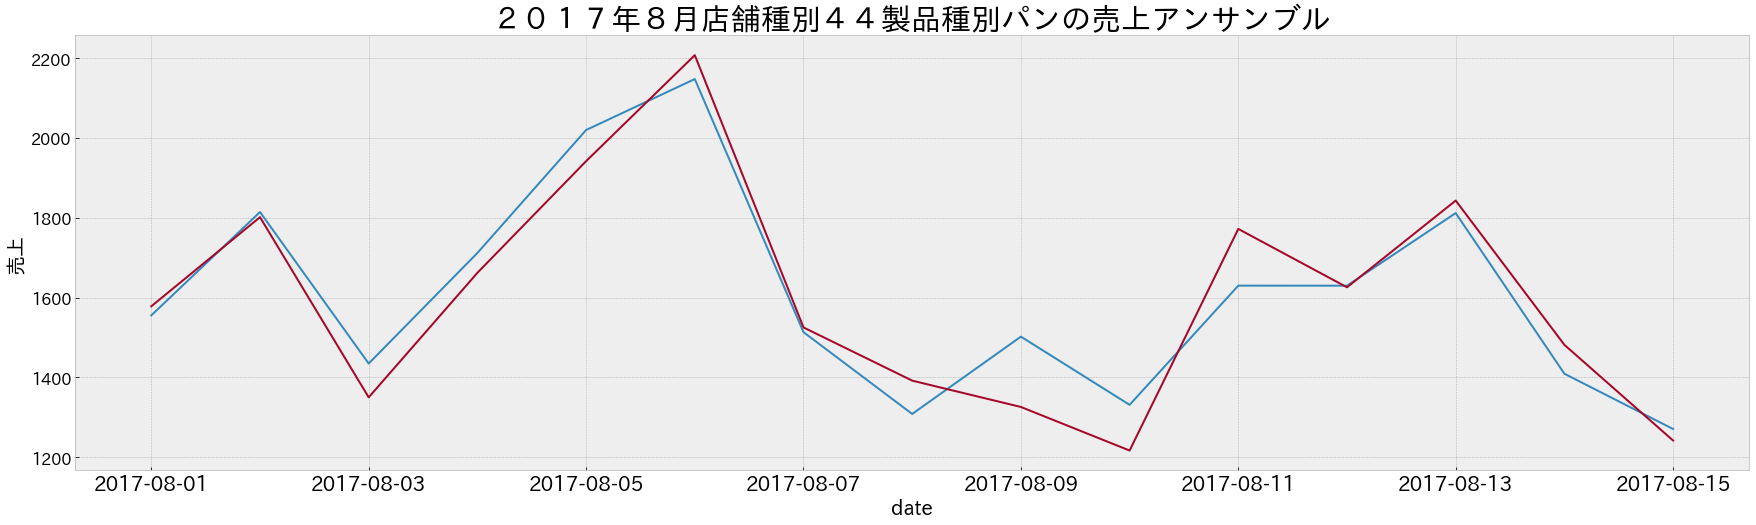

In [71]:
#加重平均で3つのモデルの平均値を算出
#LightGBMの予測値の重み付けを強くに、XGBoostを弱くする。
mean = prediction_446_pca_umap*0.54 + prediction_446_tsne_trend*0.46
rmse_446 = np.sqrt(np.mean((y_valid_446 - mean)**2))
# rmsle=np.sqrt(mean_squared_error(np.log1p(y_valid),np.log1p(prediction)))
r2_446=r2_score(y_valid_446,mean)
 
#予測値の結果確認
rmsle_446=rmsle(y_valid_446, mean)

print(f"誤差(MSE) = {mean_squared_error(y_valid_446, mean)}")
print(f"誤差(RMSE) = {rmse_446}")
print(f"誤差(RMSLE) = {rmsle_446}")
print(f"誤差(R2) = {r2_446}")


plt.figure(figsize=(30, 8))
plt.title("２０１７年８月店舗種別４４製品種別パンの売上アンサンブル", fontsize=30)
plt.xticks(fontsize= 20)
plt.yticks(fontsize= 16)
plt.ylabel('売上', fontsize=20)
plt.xlabel('date', fontsize=20)
# plt.legend( bbox_to_anchor=(0.0, 0.78, 0.28, 0.102),fontsize=20)
# sns.lineplot(x=b, y=a,label='prediction')
# sns.lineplot(x=b, y=y_valid.values,label='true')
sns.lineplot(x=X_valid_446.index, y=mean)
sns.lineplot(x=X_valid_446.index, y=y_valid_446)

C:\Users\PCHNe\AppData\Local\Temp\ipykernel_26304\503394738.py:6: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


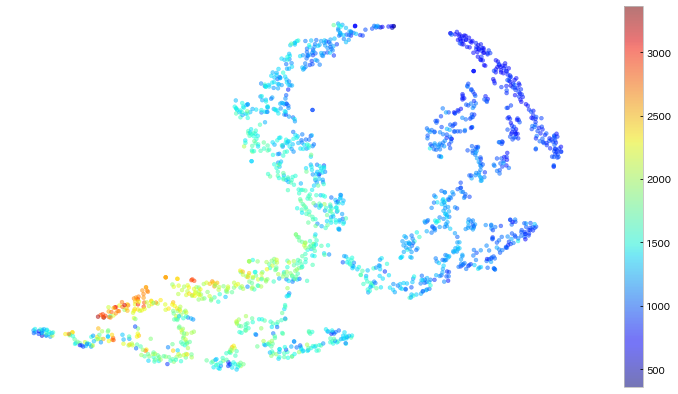

In [72]:
plt.figure(figsize=(13, 7))
plt.scatter(X_reduced_tsne[:, 0], X_reduced_tsne[:, 1],
            c=y_446, cmap='jet',
            s=15, alpha=0.5)
plt.axis('off')
plt.colorbar()
plt.show()

In [ ]:
from sklearn.cross_decomposition import PLSRegression
pls=PLSRegression(n_components=7)
ff=f.drop(f.columns[np.isnan(f).any()], axis=1)
X_446 = ff[features].copy()
y_446 = ff.sales.copy()
X_train_446 = X_446['2013-01-01' : '2017-07-31']
y_train_446 = y_446['2013-01-01' : '2017-07-31']
X_valid_446 = X_446['2017-08-01' : ]
y_valid_446 = y_446['2017-08-01' : ]

In [ ]:

pls.fit(X_train_446,y_train_446)


PLSRegression(n_components=7)

In [ ]:

print(f'train score:{pls.score(X_train_446,y_train_446)}')
print(f'valid score:{pls.score(X_valid_446,y_valid_446)}')

train score:0.6507488148131846
valid score:0.1273063004587781


In [ ]:
catboost=pd.DataFrame(prediction,columns=['prediction'],index=X_valid.index)
catboost

,prediction
date,
2017-08-01,0.000000
2017-08-01,0.000000
2017-08-01,0.000000
2017-08-01,2493.467427
2017-08-01,0.000000
...,...
2017-08-15,422.987362
2017-08-15,99.752504
2017-08-15,2318.837486
